In [2]:
!uv pip install ultralytics
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)


In [3]:
!apt-get install zip

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zip is already the newest version (3.0-12build2).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [4]:
import os
import random
import shutil
from pathlib import Path

source = "/content/drive/MyDrive/extracted_frames"
target = "/content/final_dataset"

classes = ["High-risk incident", "Low-risk incident"]
split_ratio = 0.8

# Clean target directory to start fresh
if os.path.exists(target):
    shutil.rmtree(target)

for cls in classes:
    cls_path = Path(source) / cls
    if not cls_path.exists():
        print(f"Warning: Path {cls_path} not found.")
        continue

    # Recursively find all image files in subfolders
    images = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp']:
        images.extend(list(cls_path.rglob(ext)))

    random.shuffle(images)

    split_idx = int(len(images) * split_ratio)
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    os.makedirs(f"{target}/train/{cls}", exist_ok=True)
    os.makedirs(f"{target}/val/{cls}", exist_ok=True)

    print(f"Copying {len(train_imgs)} training and {len(val_imgs)} validation images for {cls}...")

    for img_path in train_imgs:
        # Using name to keep the filename, but copying from nested path
        shutil.copy(str(img_path), os.path.join(target, 'train', cls, img_path.name))

    for img_path in val_imgs:
        shutil.copy(str(img_path), os.path.join(target, 'val', cls, img_path.name))

print("Done")

Copying 383 training and 96 validation images for High-risk incident...
Copying 2996 training and 749 validation images for Low-risk incident...
Done


In [5]:
from ultralytics import YOLO
import os

model = YOLO("yolo11l-cls.pt")

results = model.train(
    data="/content/final_dataset",
    epochs=35,
    imgsz=224,
    batch=16,
    device=0,
    workers=4
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

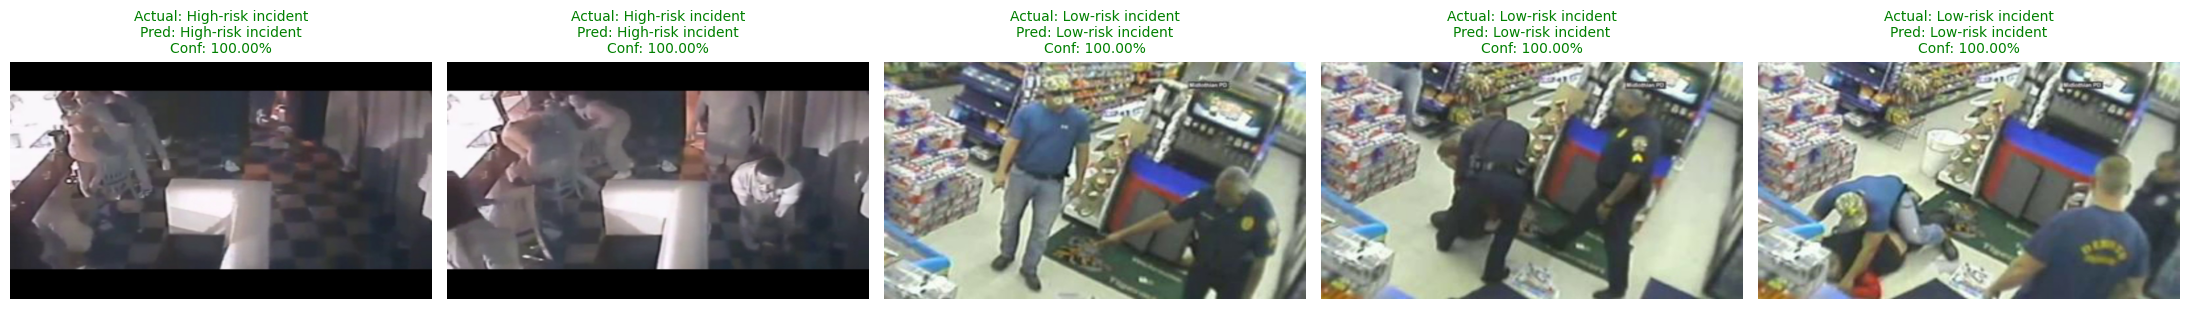

In [7]:
from ultralytics import YOLO
import torch
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load the best trained model
model_path = '/content/runs/classify/train/weights/best.pt'
model = YOLO(model_path)

# 2. Select a diverse sample (High-risk vs Low-risk)
base_path = Path('/content/drive/MyDrive/extracted_frames')
high_risk_imgs = list((base_path / 'High-risk incident').rglob('*.jpg')) + list((base_path / 'High-risk incident').rglob('*.png'))
low_risk_imgs = list((base_path / 'Low-risk incident').rglob('*.jpg')) + list((base_path / 'Low-risk incident').rglob('*.png'))

# Select 2 high-risk and 3 low-risk for variation
test_samples = random.sample(high_risk_imgs, 2) + random.sample(low_risk_imgs, 3)
random.shuffle(test_samples)

# 3. Predict and Display Results
fig, axes = plt.subplots(1, 5, figsize=(22, 7))

for i, img_path in enumerate(test_samples):
    results = model(img_path, verbose=False)[0]
    probs = results.probs
    top1_idx = probs.top1
    top1_conf = probs.top1conf.item()
    label = results.names[top1_idx]

    # Display
    img = Image.open(img_path)
    axes[i].imshow(img)
    actual_label = img_path.parent.parent.name # Gets the class folder name
    axes[i].set_title(f"Actual: {actual_label}\nPred: {label}\nConf: {top1_conf:.2%}",
                      color=('green' if label == actual_label else 'red'), fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()